In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind

In [2]:
np.random.seed(0)
n_users = 1000
groups = np.random.choice(['A', 'B'], size=n_users)
conversion = []

for group in groups:
    if group == 'A':
        conversion.append(np.random.binomial(1, 0.25))
    else:
        conversion.append(np.random.binomial(1, 0.30))

data = pd.DataFrame({
    'Group': groups,
    'Converted': conversion
})

data.head()

,Group,Converted
0,A,0
1,B,0
2,B,0
3,A,1
4,B,0


In [3]:
data.head()
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Group      1000 non-null   object
 1   Converted  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


Group        0
Converted    0
dtype: int64

In [4]:
data['Group'].value_counts()

Group
B    504
A    496
Name: count, dtype: int64

In [5]:
conversion_rate = data.groupby('Group')['Converted'].mean()
print(conversion_rate)

Group
A    0.262097
B    0.309524
Name: Converted, dtype: float64


In [6]:
lift = ((conversion_rate['B'] - conversion_rate['A']) / conversion_rate['A']) * 100
print(f"Lift: {lift:.2f}%")

Lift: 18.10%


In [7]:
group_A = data[data['Group'] == 'A']['Converted']
group_B = data[data['Group'] == 'B']['Converted']

In [8]:
t_stat, p_value = stats.ttest_ind(group_A, group_B)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.6600225686095378
P-value: 0.09722405700245744


In [9]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("Version B performs significantly different from Version A.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant difference found.")

Fail to Reject the Null Hypothesis
No statistically significant difference found.


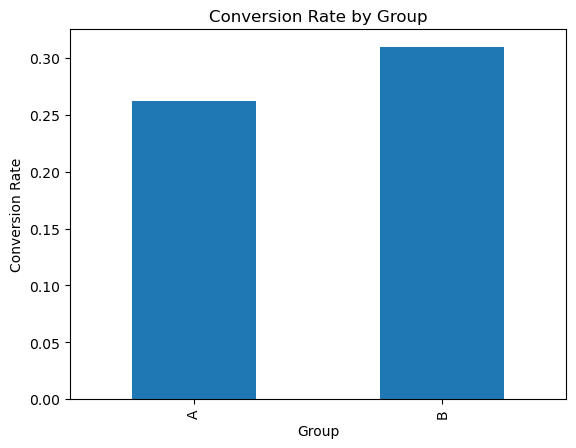

In [10]:
conversion_rate.plot(kind='bar')

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

In [12]:
print("Conversion Rate")
print(conversion_rate)
print(f"\nLift: {lift:.2f}%")
print(f"P-value: {p_value:.4f}")

Conversion Rate
Group
A    0.262097
B    0.309524
Name: Converted, dtype: float64

Lift: 18.10%
P-value: 0.0972
